In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings("ignore", category=IntegrationWarning)

In [2]:
fc = 0.4
ve = 20
follow_up = 1.5
tau = 1.5
df_results = pd.read_csv(f'./sim_outputs_1000/estimations_fc{fc}_ve{ve}_counter.csv')

In [3]:
# Rename columns to easier variable names
df_n_04 = df_results[df_results["noise_level"]==0.4].copy()
df_n_04 = df_n_04.rename(columns={
    'ate_classic RMST': 'ate_classic',
    'var_classic RMST': 'var_classic',
    'ate_ppi_shifted_order RMST': 'ate_ppi',
    'var_ppi_shifted_order RMST': 'var_ppi',
})

# True ATE
lambda_c = -np.log(1 - fc) / follow_up
lambda_v = (1 - ve / 100) * lambda_c
rmst_control = (1 - np.exp(-lambda_c * tau)) / lambda_c
rmst_vaccine = (1 - np.exp(-lambda_v * tau)) / lambda_v
TRUE_ATE = rmst_vaccine - rmst_control

def summarize(group):
    out = {}

    # ---- Classic estimator ----
    est = group['ate_classic']
    var_hat = group['var_classic']

    out['bias_classic'] = est.mean() - TRUE_ATE
    out['emp_var_classic'] = est.var(ddof=1)
    out['mean_varhat_classic'] = var_hat.mean()
    out['MSE_classic'] = np.mean((est - TRUE_ATE)**2)
    out['RMSE_classic'] = np.sqrt(out['MSE_classic'])

    # 95% CI coverage
    halfwidth = 1.96 * np.sqrt(var_hat)
    L = est - halfwidth
    U = est + halfwidth
    out['coverage_classic'] = np.mean((TRUE_ATE >= L) & (TRUE_ATE <= U))

    # ---- PPI estimator ----
    est = group['ate_ppi']
    var_hat = group['var_ppi']

    out['bias_ppi'] = est.mean() - TRUE_ATE
    out['emp_var_ppi'] = est.var(ddof=1)
    out['mean_varhat_ppi'] = var_hat.mean()
    out['MSE_ppi'] = np.mean((est - TRUE_ATE)**2)
    out['RMSE_ppi'] = np.sqrt(out['MSE_ppi'])

    # 95% CI coverage
    halfwidth = 1.96 * np.sqrt(var_hat)
    L = est - halfwidth
    U = est + halfwidth
    out['coverage_ppi'] = np.mean((TRUE_ATE >= L) & (TRUE_ATE <= U))

    return pd.Series(out)


summary_by_n = df_n_04.groupby('n').apply(summarize).reset_index()
summary_by_n


/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_28449/978935240.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_n = df_n_04.groupby('n').apply(summarize).reset_index()


,n,bias_classic,emp_var_classic,mean_varhat_classic,MSE_classic,RMSE_classic,coverage_classic,bias_ppi,emp_var_ppi,mean_varhat_ppi,MSE_ppi,RMSE_ppi,coverage_ppi
0,30,-0.000007,0.014551,0.014628,0.014537,0.120567,0.953,-0.004246,0.011565,0.012530,0.011572,0.107572,0.956
1,100,0.000392,0.004283,0.004399,0.004279,0.065417,0.956,-0.001054,0.003271,0.003823,0.003269,0.057174,0.968
2,1000,-0.000110,0.000428,0.000439,0.000427,0.020670,0.957,-0.000172,0.000315,0.000382,0.000315,0.017740,0.970


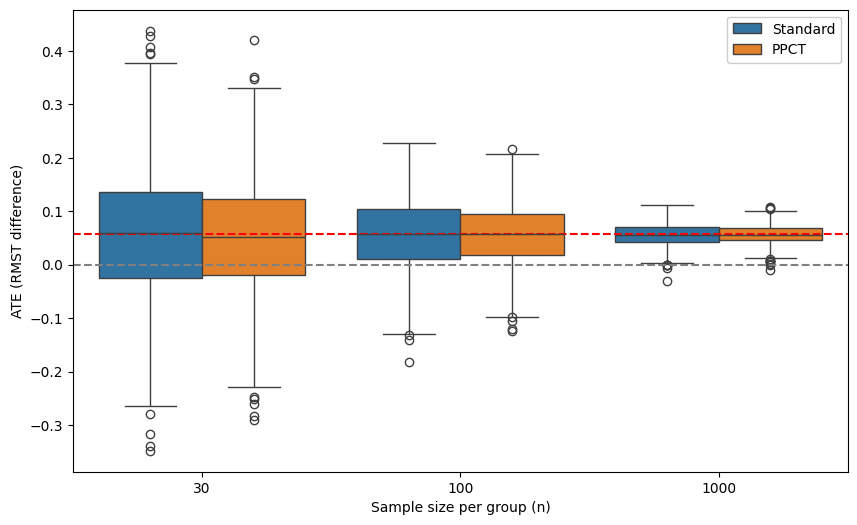

In [4]:
def vectorialize_ate(df, col):
    d = df[[col, 'n']].copy()
    d.rename(columns={col:"ATE estimated"}, inplace=True)
    d["Estimator"] = col
    return d

noise_level = 0.4
esti = df_results[df_results["noise_level"]==noise_level].copy()
esti.rename(columns={'ate_classic RMST':'Standard', 
                    'ate_ppi_shifted_order RMST':'PPCT'}, 
            inplace=True)
esti.drop(columns=['r2_shifted_order RMST','sim'], inplace=True)

esti = pd.concat([vectorialize_ate(esti, col) for col in ['Standard', 'PPCT']], axis=0)
#Use variance results from previous simulation
vari = df_results[df_results["noise_level"]==0.2].copy()
vari.rename(columns={'var_classic RMST':'Standard', 
                    'var_ppi_shifted_order RMST':'PPCT',
                    #"var_ppi RMST_fixed_lambda": "PPCT fixed lambda"
                    }, 
            inplace=True)
def vectorialize_var(df, col):
    d = df[[col, 'n']].copy()
    d.rename(columns={col:"VAR estimated"}, inplace=True)
    d["Estimator"] = col
    return d
vari.drop(columns=['r2_shifted_order RMST', 'sim'], inplace=True)
vari = pd.concat([vectorialize_var(vari, col) for col in ['Standard','PPCT']], axis=0)

plot_data = esti.copy()
plot_data = plot_data.reset_index(drop=True)

# Plot
plt.figure(figsize=(10,6))
sns.boxplot(data=plot_data, x="n", y="ATE estimated", hue="Estimator")
plt.yticks(fontsize=10)
plt.axhline(TRUE_ATE, color='red', linestyle='--')
plt.axhline(0, color='gray', linestyle='--')
plt.legend(loc='upper right', framealpha=1.)
plt.ylabel("ATE (RMST difference)")
plt.xlabel("Sample size per group (n)")
plt.show()

/Users/maylis.tran/miniforge3/envs/leaspy_v2/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


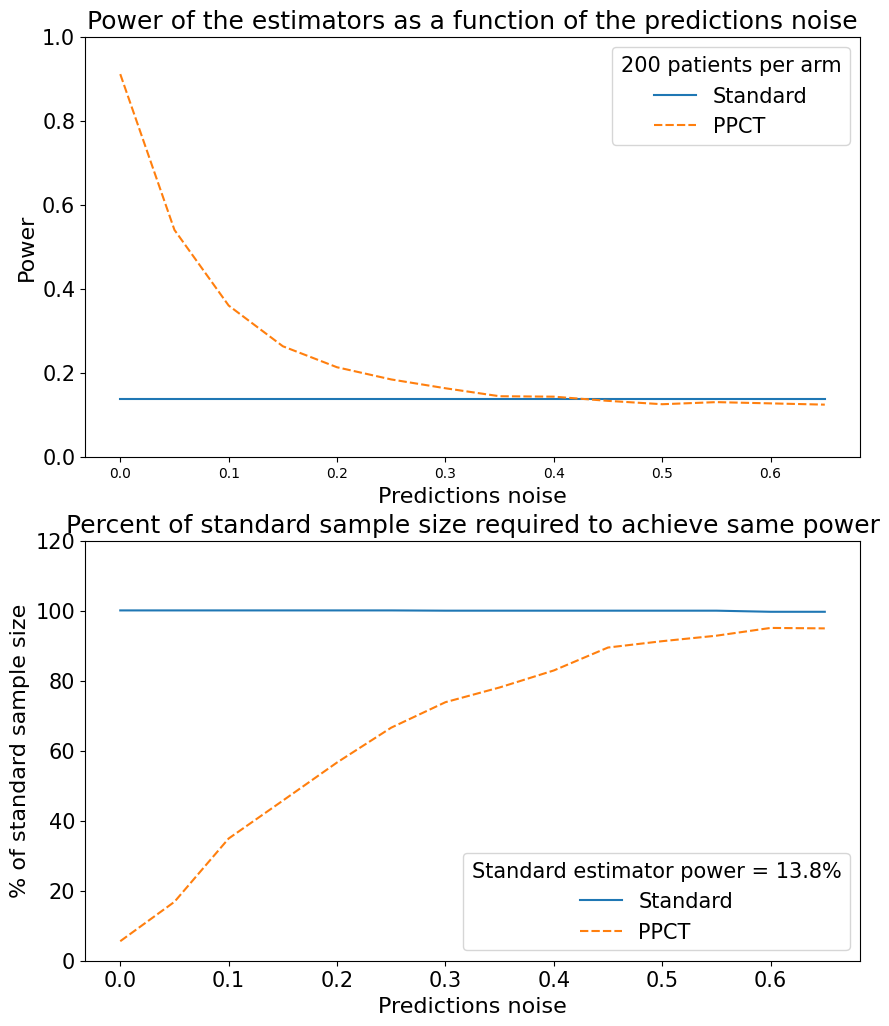

In [5]:
plt.figure(figsize=(10,12))
plt.subplot(2,1,1)
plt.rcParams.update({'font.size': 15})
power = df_results[["n", "noise_level", 
                               "ate_classic RMST", 
                               "ate_ppi_shifted_order RMST", 
                               "var_classic RMST", 
                               "var_ppi_shifted_order RMST"]].copy()
var_map = {
    'ate_classic RMST': 'var_classic RMST',
    'ate_ppi_shifted_order RMST': 'var_ppi_shifted_order RMST'
}

for col in ['ate_classic RMST', 'ate_ppi_shifted_order RMST']:
    ci = power[col] / np.sqrt(df_results[var_map[col]])
    reject = np.abs(ci) > 1.96
    power[col] = reject.values

mean_power = power.groupby(["n", "noise_level"]).mean().sort_index().drop(columns=['var_classic RMST','var_ppi_shifted_order RMST'])
mean_power.rename(columns={'ate_classic RMST':'Standard', 'ate_ppi_shifted_order RMST':'PPCT'}, inplace=True)

# First plot
sns.lineplot(mean_power.loc[100]) 
plt.yticks(fontsize=15)
plt.ylim(0,1)
plt.xlabel("Predictions noise",fontsize=16)
plt.ylabel("Power",fontsize=16)
plt.legend(
    title="200 patients per arm",
    loc="upper right",
    fontsize=15,
    title_fontsize=15
)
plt.title("Power of the estimators as a function of the predictions noise", fontsize=18) # added n=200


# Second plot
plt.subplot(2,1,2)
nreps = 1000
mean_var = power.iloc[nreps:2*nreps].groupby("noise_level").mean().sort_index().drop(columns=['n','ate_classic RMST','ate_ppi_shifted_order RMST'])
mean_var.rename(columns={'var_classic RMST':'Standard', 'var_ppi_shifted_order RMST':'PPCT'}, inplace=True)

power_standard_n0 = mean_power.loc[(100, 0), "Standard"]

sns.lineplot(mean_var / power.iloc[nreps:2*nreps]["var_classic RMST"].mean() * 100)
plt.ylim(0,120)
plt.yticks(fontsize=15)
plt.xlabel("Predictions noise",fontsize=16)
plt.ylabel("% of standard sample size",fontsize=16)

# Custom legend text
plt.legend(
    title=f"Standard estimator power = {power_standard_n0*100:.1f}%",
    loc="lower right",
    fontsize=15,
    title_fontsize=15
)

plt.title("Percent of standard sample size required to achieve same power", fontsize=18)
plt.show()
